# Crop Handwriting Image into Lines
Each section below is a **separate attempt** with its own imports and cells.

- Input: `whole image/WhatsApp Image 2026-04-13 at 12.40.53.jpeg`
- Output: `cropped image to lines/`

---
## Attempt 1 - Horizontal Projection Profile (Row Sum)
Sum dark pixels per row. Valleys (low sum) between lines = cut points.

In [10]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

IMG_DIR = "whole image"
OUT_DIR = "cropped image to lines/attempt1"
os.makedirs(OUT_DIR, exist_ok=True)

images = glob.glob(os.path.join(IMG_DIR, "*"))
IMG_PATH = images[0]
print(f"Loading: {IMG_PATH}")

img   = cv2.imread(IMG_PATH)
gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Row-wise sum of ink pixels
row_sums = np.sum(binary, axis=1)

plt.figure(figsize=(12, 4))
plt.plot(row_sums)
plt.title("Horizontal Projection Profile")
plt.xlabel("Row")
plt.ylabel("Ink pixels")
plt.show()

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


Found 25 lines


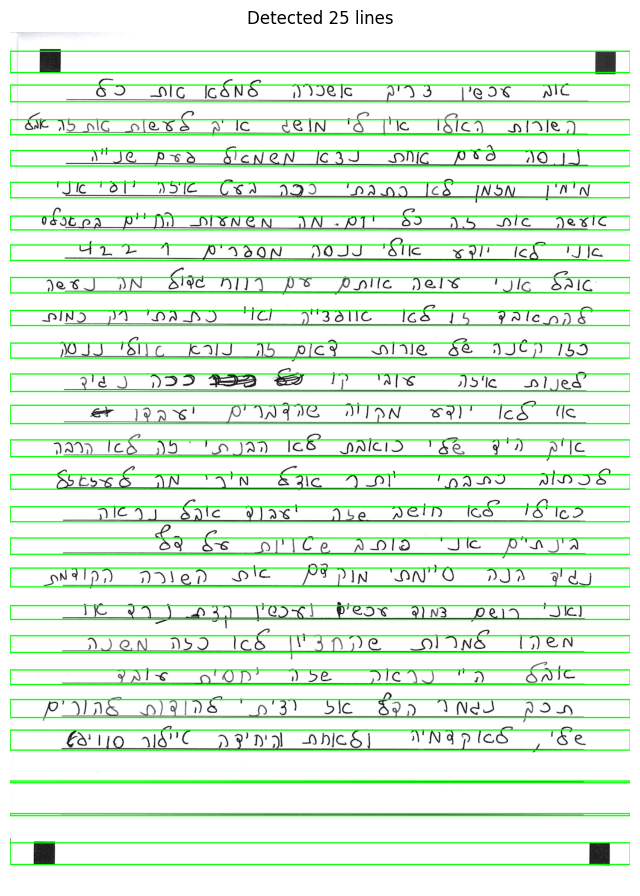

In [2]:
# Find valleys (gaps between lines)
threshold = row_sums.max() * 0.05
in_line   = row_sums > threshold

lines = []
start = None
for i, val in enumerate(in_line):
    if val and start is None:
        start = i
    elif not val and start is not None:
        lines.append((start, i))
        start = None
if start is not None:
    lines.append((start, len(in_line)))

MIN_GAP = 10
merged = [lines[0]]
for s, e in lines[1:]:
    if s - merged[-1][1] < MIN_GAP:
        merged[-1] = (merged[-1][0], e)
    else:
        merged.append((s, e))

print(f"Found {len(merged)} lines")

vis = img.copy()
for s, e in merged:
    cv2.rectangle(vis, (0, s), (img.shape[1], e), (0, 255, 0), 2)
plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"Detected {len(merged)} lines")
plt.axis("off")
plt.show()

In [3]:
PADDING = 5
for i, (s, e) in enumerate(merged):
    y1 = max(0, s - PADDING)
    y2 = min(img.shape[0], e + PADDING)
    crop = img[y1:y2, :]
    out_path = os.path.join(OUT_DIR, f"line_{i+1:02d}.jpg")
    cv2.imwrite(out_path, crop)
    print(f"Saved {out_path}  ({crop.shape[0]}x{crop.shape[1]})")

Saved cropped image to lines/attempt1\line_01.jpg  (61x1486)
Saved cropped image to lines/attempt1\line_02.jpg  (50x1486)
Saved cropped image to lines/attempt1\line_03.jpg  (46x1486)
Saved cropped image to lines/attempt1\line_04.jpg  (47x1486)
Saved cropped image to lines/attempt1\line_05.jpg  (47x1486)
Saved cropped image to lines/attempt1\line_06.jpg  (43x1486)
Saved cropped image to lines/attempt1\line_07.jpg  (47x1486)
Saved cropped image to lines/attempt1\line_08.jpg  (47x1486)
Saved cropped image to lines/attempt1\line_09.jpg  (46x1486)
Saved cropped image to lines/attempt1\line_10.jpg  (46x1486)
Saved cropped image to lines/attempt1\line_11.jpg  (52x1486)
Saved cropped image to lines/attempt1\line_12.jpg  (54x1486)
Saved cropped image to lines/attempt1\line_13.jpg  (50x1486)
Saved cropped image to lines/attempt1\line_14.jpg  (45x1486)
Saved cropped image to lines/attempt1\line_15.jpg  (46x1486)
Saved cropped image to lines/attempt1\line_16.jpg  (49x1486)
Saved cropped image to l

---
## Attempt 2 - Morphological Dilation + Contours
Dilate ink horizontally so each text line becomes one big blob, then find bounding boxes.

In [9]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

IMG_DIR = "whole image"
OUT_DIR = "cropped image to lines/attempt2"
os.makedirs(OUT_DIR, exist_ok=True)

images = glob.glob(os.path.join(IMG_DIR, "*"))
IMG_PATH = images[0]
print(f"Loading: {IMG_PATH}")

img   = cv2.imread(IMG_PATH)
gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Wide horizontal kernel merges all words in a line into one blob
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (img.shape[1] // 2, 5))
dilated = cv2.dilate(binary, kernel, iterations=1)

plt.figure(figsize=(8, 12))
plt.imshow(dilated, cmap="gray")
plt.title("After horizontal dilation")
plt.axis("off")
plt.show()

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


Found 27 line regions


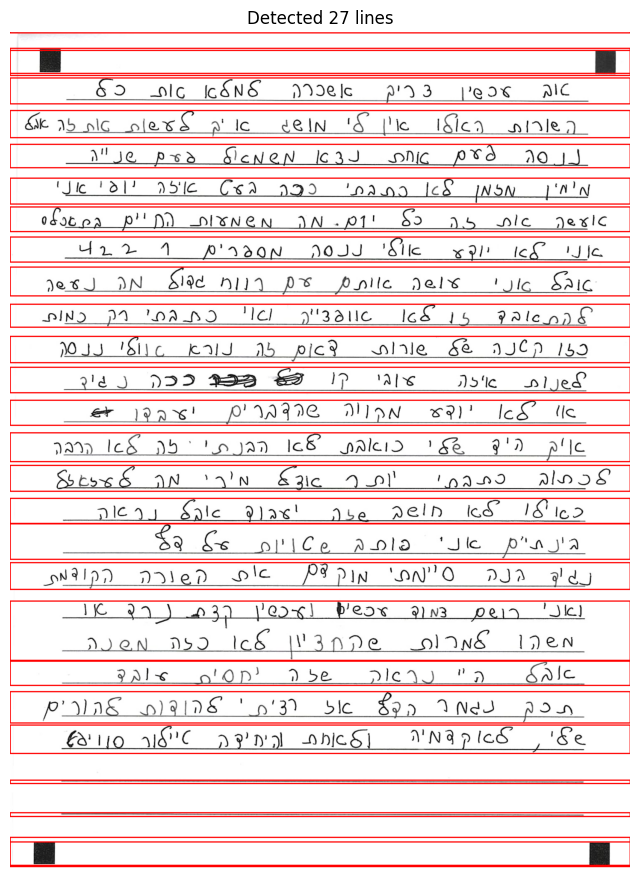

In [5]:
contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

boxes = [cv2.boundingRect(c) for c in contours]
boxes = sorted(boxes, key=lambda b: b[1])

print(f"Found {len(boxes)} line regions")

vis = img.copy()
for x, y, w, h in boxes:
    cv2.rectangle(vis, (0, y), (img.shape[1], y + h), (0, 0, 255), 2)
plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"Detected {len(boxes)} lines")
plt.axis("off")
plt.show()

In [6]:
PADDING = 5
for i, (x, y, w, h) in enumerate(boxes):
    y1 = max(0, y - PADDING)
    y2 = min(img.shape[0], y + h + PADDING)
    crop = img[y1:y2, :]
    out_path = os.path.join(OUT_DIR, f"line_{i+1:02d}.jpg")
    cv2.imwrite(out_path, crop)
    print(f"Saved {out_path}  ({crop.shape[0]}x{crop.shape[1]})")

Saved cropped image to lines/attempt2\line_01.jpg  (9x1486)
Saved cropped image to lines/attempt2\line_02.jpg  (70x1486)
Saved cropped image to lines/attempt2\line_03.jpg  (70x1486)
Saved cropped image to lines/attempt2\line_04.jpg  (72x1486)
Saved cropped image to lines/attempt2\line_05.jpg  (75x1486)
Saved cropped image to lines/attempt2\line_06.jpg  (66x1486)
Saved cropped image to lines/attempt2\line_07.jpg  (72x1486)
Saved cropped image to lines/attempt2\line_08.jpg  (69x1486)
Saved cropped image to lines/attempt2\line_09.jpg  (70x1486)
Saved cropped image to lines/attempt2\line_10.jpg  (79x1486)
Saved cropped image to lines/attempt2\line_11.jpg  (65x1486)
Saved cropped image to lines/attempt2\line_12.jpg  (73x1486)
Saved cropped image to lines/attempt2\line_13.jpg  (71x1486)
Saved cropped image to lines/attempt2\line_14.jpg  (70x1486)
Saved cropped image to lines/attempt2\line_15.jpg  (79x1486)
Saved cropped image to lines/attempt2\line_16.jpg  (72x1486)
Saved cropped image to li

---
## Attempt 3 - Smoothed Projection with Gaussian Filter
Same idea as Attempt 1 but smoothing the projection curve first avoids false splits from noise, ascenders, or descenders.

Loading: whole image\4_6010333047398866303_page-0002.jpg


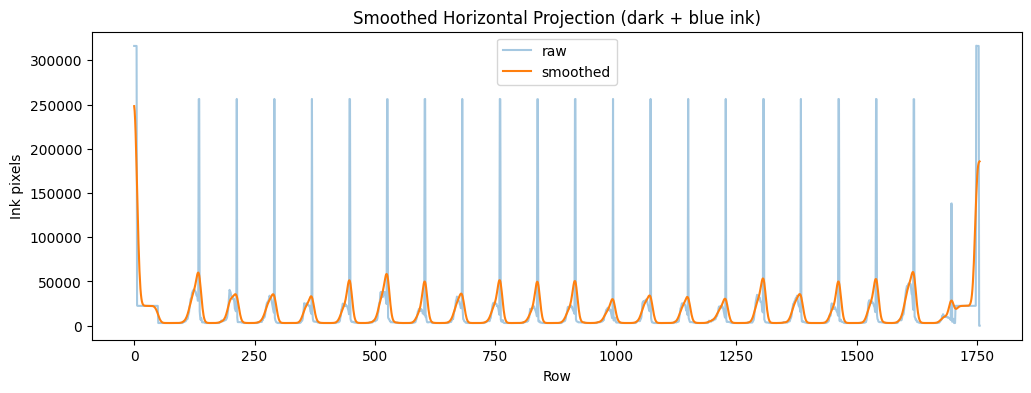

In [7]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

IMG_DIR = "whole image"
OUT_DIR = "cropped image to lines/attempt3"
os.makedirs(OUT_DIR, exist_ok=True)

images = glob.glob(os.path.join(IMG_DIR, "*"))
IMG_PATH = images[0]
print(f"Loading: {IMG_PATH}")

img = cv2.imread(IMG_PATH)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Mask 1: dark ink (black pen) via Otsu on grayscale
_, dark_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Mask 2: blue ink via HSV color range (hue 90-130 covers most blue pen shades)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
blue_mask = cv2.inRange(hsv, (90, 40, 40), (130, 255, 255))

# Combine both masks so either dark or blue ink counts as ink
binary = cv2.bitwise_or(dark_mask, blue_mask)

row_sums = np.sum(binary, axis=1).astype(float)
smoothed = gaussian_filter1d(row_sums, sigma=5)

plt.figure(figsize=(12, 4))
plt.plot(row_sums, alpha=0.4, label="raw")
plt.plot(smoothed, label="smoothed")
plt.legend()
plt.title("Smoothed Horizontal Projection (dark + blue ink)")
plt.xlabel("Row")
plt.ylabel("Ink pixels")
plt.show()

Found 22 lines


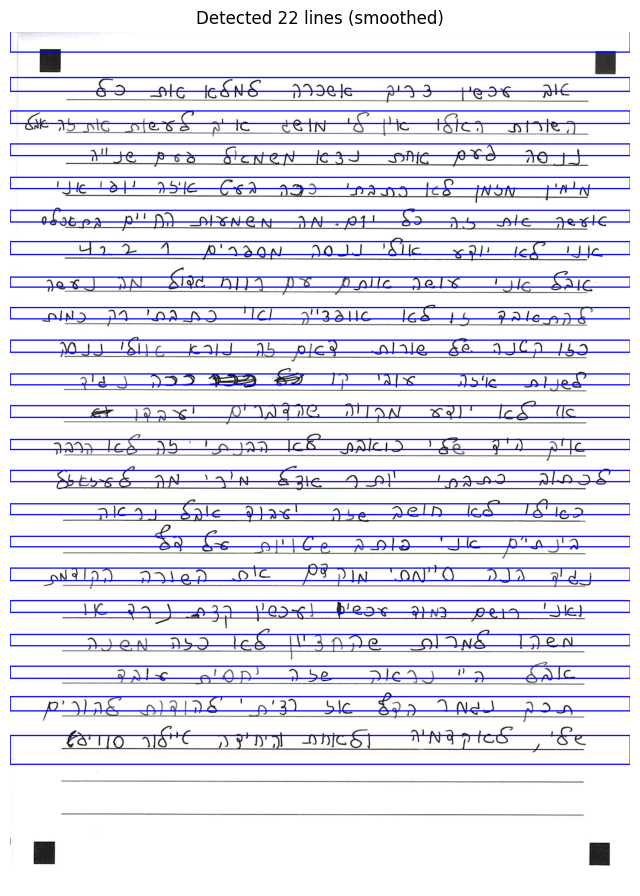

In [36]:
threshold = smoothed.max() * 0.05
in_line   = smoothed > threshold

lines = []
start = None
for i, val in enumerate(in_line):
    if val and start is None:
        start = i
    elif not val and start is not None:
        lines.append((start, i))
        start = None
if start is not None:
    lines.append((start, len(in_line)))

MIN_GAP = 8
merged = [lines[0]]
for s, e in lines[1:]:
    if s - merged[-1][1] < MIN_GAP:
        merged[-1] = (merged[-1][0], e)
    else:
        merged.append((s, e))

print(f"Found {len(merged)} lines")

vis = img.copy()
for s, e in merged:
    cv2.rectangle(vis, (0, s), (img.shape[1], e), (255, 0, 0), 2)
plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"Detected {len(merged)} lines (smoothed)")
plt.axis("off")
plt.show()

In [6]:
PADDING = 5
for i, (s, e) in enumerate(merged):
    y1 = max(0, s - PADDING)
    y2 = min(img.shape[0], e + PADDING)
    crop = img[y1:y2, :]
    out_path = os.path.join(OUT_DIR, f"line_{i+1:02d}.jpg")
    cv2.imwrite(out_path, crop)
    print(f"Saved {out_path}  ({crop.shape[0]}x{crop.shape[1]})")

Saved cropped image to lines/attempt3\line_01.jpg  (51x1242)
Saved cropped image to lines/attempt3\line_02.jpg  (73x1242)
Saved cropped image to lines/attempt3\line_03.jpg  (75x1242)
Saved cropped image to lines/attempt3\line_04.jpg  (75x1242)
Saved cropped image to lines/attempt3\line_05.jpg  (70x1242)
Saved cropped image to lines/attempt3\line_06.jpg  (72x1242)
Saved cropped image to lines/attempt3\line_07.jpg  (78x1242)
Saved cropped image to lines/attempt3\line_08.jpg  (70x1242)
Saved cropped image to lines/attempt3\line_09.jpg  (70x1242)
Saved cropped image to lines/attempt3\line_10.jpg  (79x1242)
Saved cropped image to lines/attempt3\line_11.jpg  (73x1242)
Saved cropped image to lines/attempt3\line_12.jpg  (71x1242)
Saved cropped image to lines/attempt3\line_13.jpg  (149x1242)
Saved cropped image to lines/attempt3\line_14.jpg  (69x1242)
Saved cropped image to lines/attempt3\line_15.jpg  (62x1242)
Saved cropped image to lines/attempt3\line_16.jpg  (64x1242)
Saved cropped image to 

---
## Attempt 4 - Ruled Line Detection (Hough Transform)
Detects the **printed horizontal lines** of the paper and crops between them. Works with this lined-paper format regardless of ink color.

---
## Attempt 4 - Ruled Line Detection (FFT on ink density)
Detects the printed horizontal lines via FFT on the ink row-sum profile.


4_6010333047398866303_page-0002.jpg
  spacing=76px, anchor=33, lines=23

ds_page-0001.jpg
  spacing=76px, anchor=10, lines=23


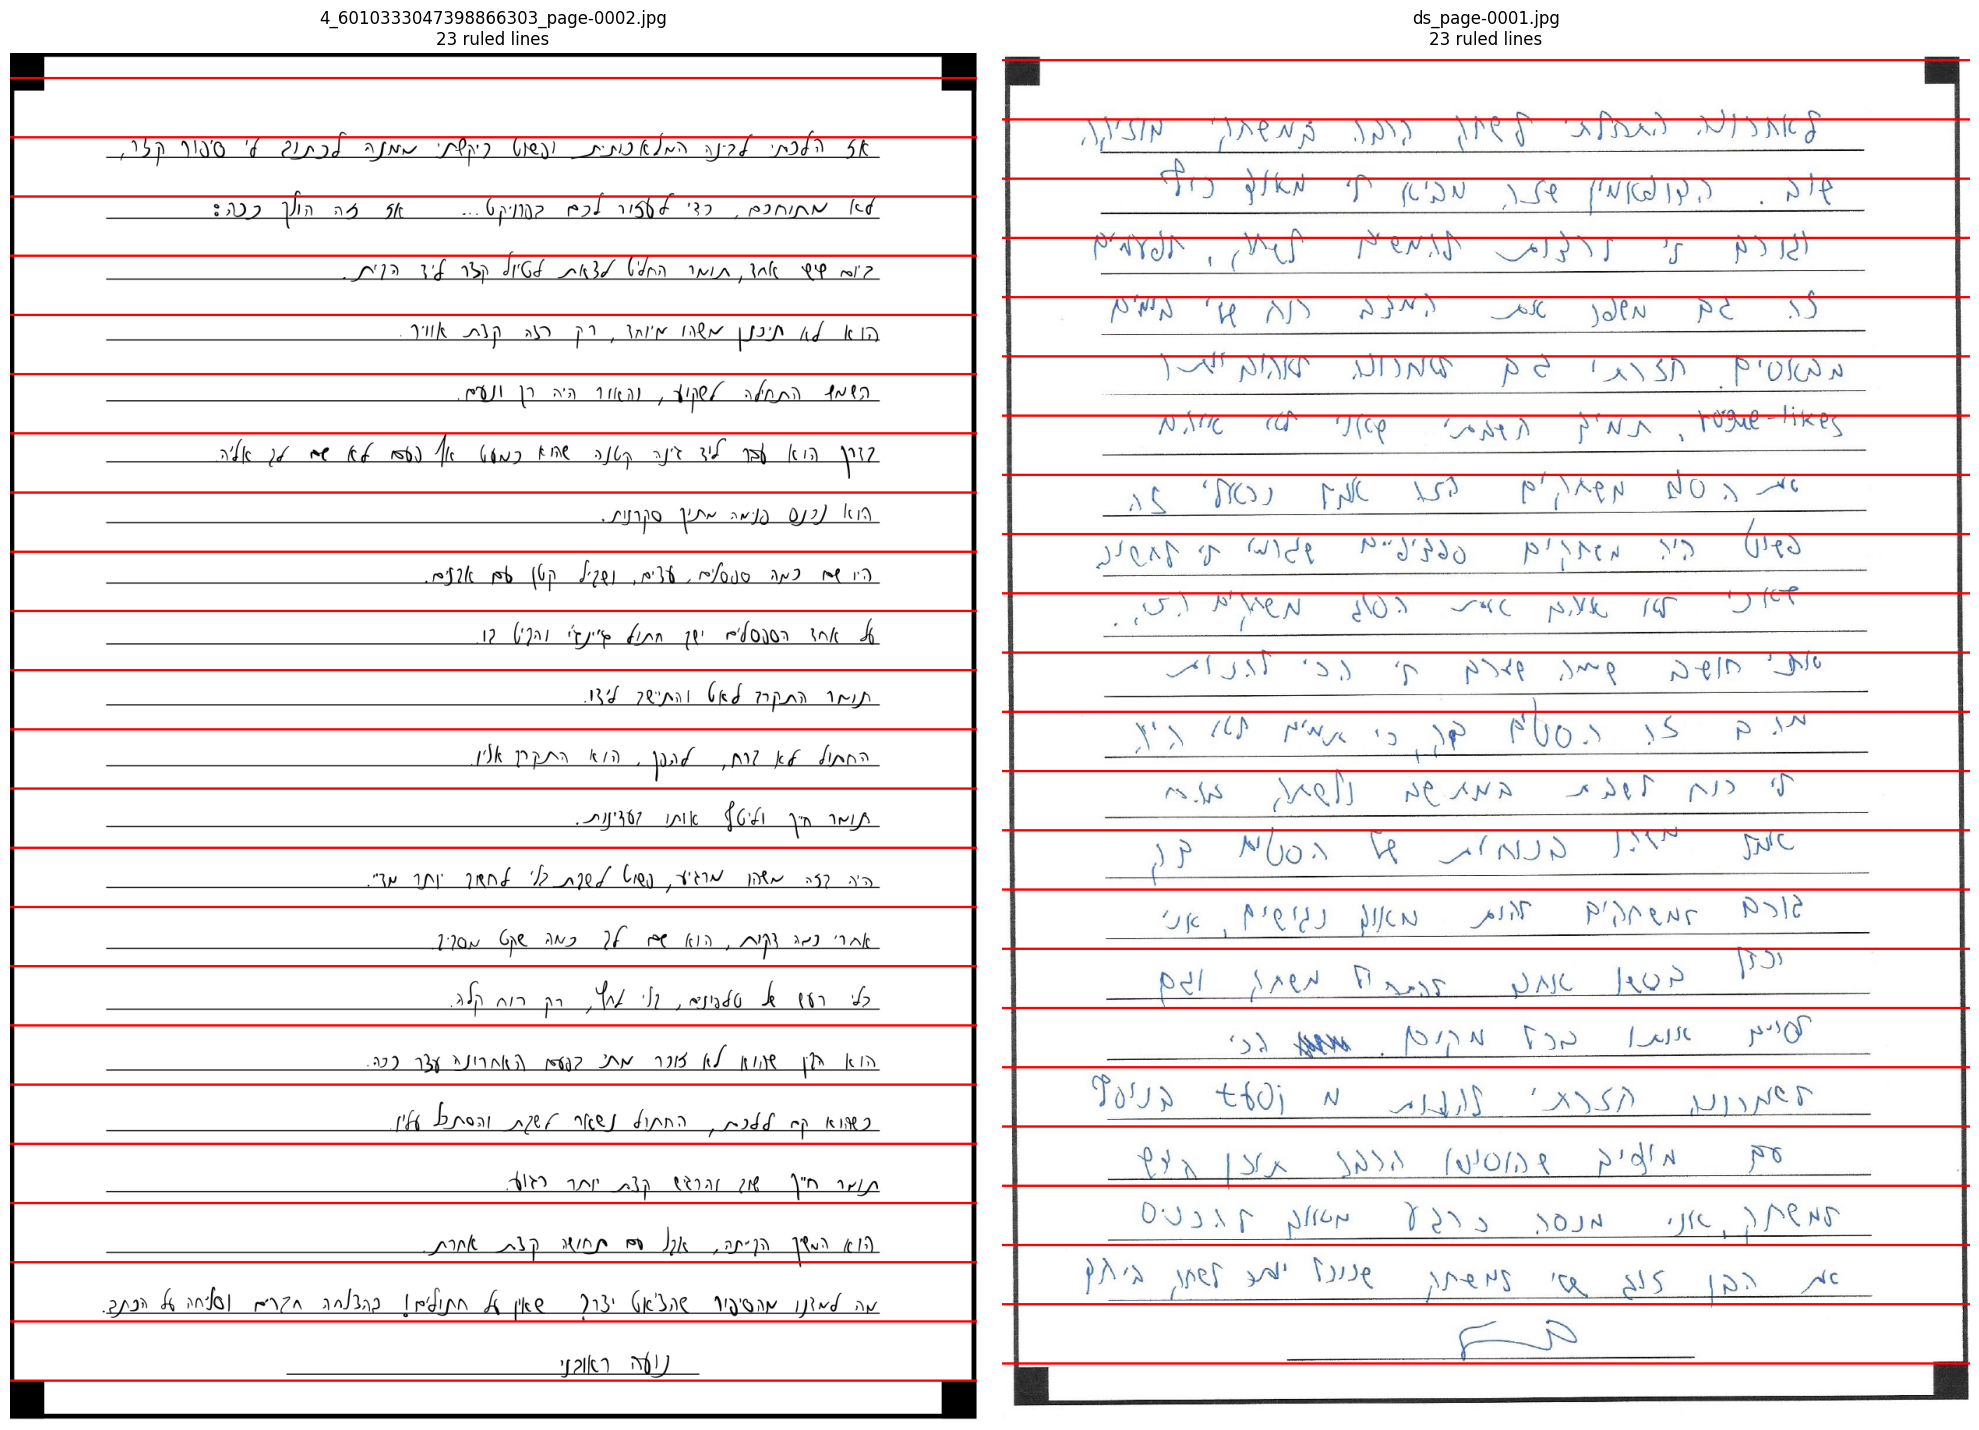

In [49]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

IMG_DIR = "whole image"
OUT_DIR = "cropped image to lines/attempt4"
os.makedirs(OUT_DIR, exist_ok=True)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16))

def detect_ruled_lines(img_path):
    img  = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    H, W = img.shape[:2]

    # Normalize for uneven scan lighting
    norm = clahe.apply(gray)

    # Ink density per row — the strong, reliable signal
    _, ink_mask = cv2.threshold(norm, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    row_sums = np.sum(ink_mask, axis=1).astype(float)
    smoothed = gaussian_filter1d(row_sums, sigma=5)

    # Invert: gaps between text rows become peaks for FFT
    signal = np.max(smoothed) - smoothed
    signal -= np.mean(signal)

    # FFT finds the exact periodicity of the text-row pattern
    fft_complex = np.fft.rfft(signal)
    fft_mag     = np.abs(fft_complex)
    fft_freqs   = np.fft.rfftfreq(H)

    # Expected: 10–40 text lines per page
    mask = (fft_freqs >= 10 / H) & (fft_freqs <= 40 / H)
    peak_idx = np.where(mask)[0][np.argmax(fft_mag[mask])]

    peak_freq = fft_freqs[peak_idx]
    spacing   = int(round(1 / peak_freq))
    phase     = np.angle(fft_complex[peak_idx])
    anchor    = int((-phase / (2 * np.pi * peak_freq)) % spacing)

    grid_ys = list(range(anchor, H, spacing))

    # Trim to written area
    ink_rows = np.where(smoothed > smoothed.max() * 0.05)[0]
    if len(ink_rows):
        grid_ys = [y for y in grid_ys
                   if ink_rows[0] - spacing <= y <= ink_rows[-1] + spacing]

    print(f"  spacing={spacing}px, anchor={anchor}, lines={len(grid_ys)}")
    return img, grid_ys

images = sorted(glob.glob(os.path.join(IMG_DIR, "*")))
fig, axes = plt.subplots(1, len(images), figsize=(10 * len(images), 14))
if len(images) == 1:
    axes = [axes]

for ax, img_path in zip(axes, images):
    print(f"\n{os.path.basename(img_path)}")
    img, grid_ys = detect_ruled_lines(img_path)
    vis = img.copy()
    for y in grid_ys:
        cv2.line(vis, (0, y), (img.shape[1], y), (0, 0, 255), 2)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{os.path.basename(img_path)}\n{len(grid_ys)} ruled lines")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
BELOW_LINE = max(1, int(img.shape[0] * 0.008))

for i in range(len(merged_ys) - 1):
    y1 = merged_ys[i] + 1
    y2 = min(img.shape[0], merged_ys[i + 1] + BELOW_LINE)
    if y2 - y1 < 5:
        continue
    crop = img[y1:y2, :]
    out_path = os.path.join(OUT_DIR, f"line_{i+1:02d}.jpg")
    cv2.imwrite(out_path, crop)
    print(f"Saved {out_path}  ({crop.shape[0]}x{crop.shape[1]})")

---
## Attempt 5 - FFT spacing + valley alignment (scan-normalized)
Uses FFT on the CLAHE-normalized ink profile to get the spacing, then snaps the grid to actual ink valleys so lines land in the gaps — not through text. Normalization is fully relative so any scan works.


4_6010333047398866303_page-0002.jpg
  spacing=76px  valleys=21  grid=23

ds_page-0001.jpg
  spacing=76px  valleys=21  grid=24


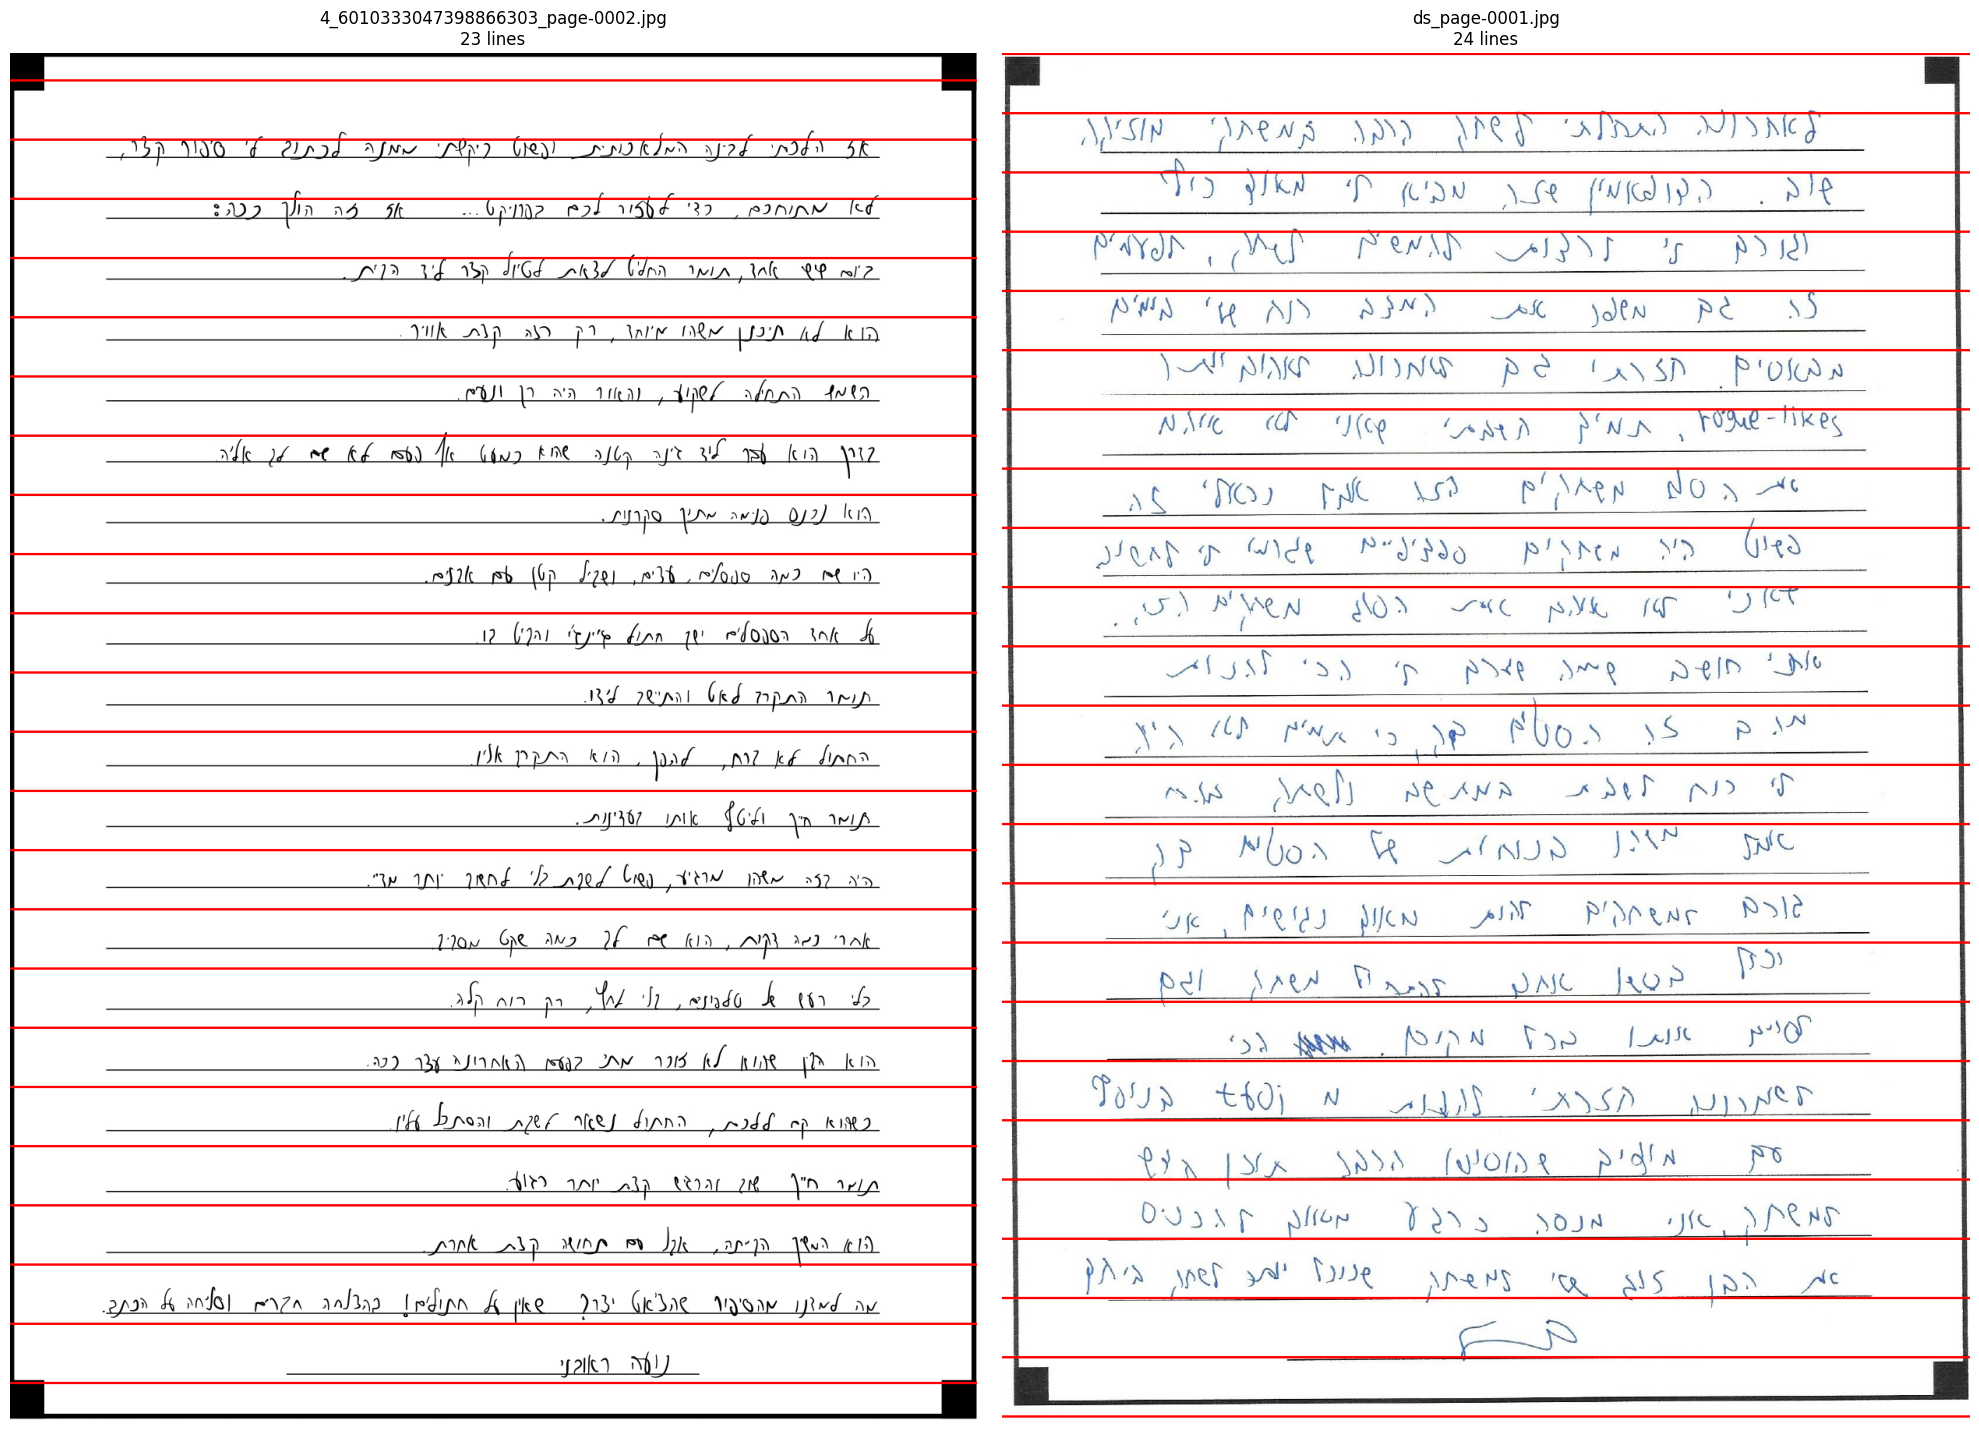

In [50]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

IMG_DIR = "whole image"
OUT_DIR = "cropped image to lines/attempt5"
os.makedirs(OUT_DIR, exist_ok=True)

def detect_lines(img_path):
    img  = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    H, W = img.shape[:2]

    # --- Normalization: makes the pipeline scan-agnostic ---
    # CLAHE fixes uneven scan lighting locally
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16))
    norm  = clahe.apply(gray)

    # Otsu on the normalized image: consistent ink/paper split on any scan
    _, ink_mask = cv2.threshold(norm, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    row_sums = np.sum(ink_mask, axis=1).astype(float)
    smoothed = gaussian_filter1d(row_sums, sigma=5)

    # Min-max normalize to 0-1 so valley thresholds are always relative
    s_min, s_max = smoothed.min(), smoothed.max()
    profile = (smoothed - s_min) / (s_max - s_min + 1e-8)

    # --- Step 1: find spacing via FFT on inverted profile (gaps = peaks) ---
    signal = 1.0 - profile
    signal -= signal.mean()
    fft_c    = np.fft.rfft(signal)
    fft_mag  = np.abs(fft_c)
    fft_freq = np.fft.rfftfreq(H)

    mask     = (fft_freq >= 10 / H) & (fft_freq <= 40 / H)
    peak_idx = np.where(mask)[0][np.argmax(fft_mag[mask])]
    spacing  = int(round(1 / fft_freq[peak_idx]))

    # --- Step 2: find actual valleys (ink-free gaps between text rows) ---
    valleys, _ = find_peaks(
        -profile,
        distance=int(spacing * 0.6),
        prominence=0.05          # relative — works on any scan
    )

    # --- Step 3: snap grid to valleys ---
    # Find the anchor (mod spacing) that lands on the most detected valleys
    tolerance = spacing * 0.25
    best_anchor, best_count = 0, 0
    for v in valleys:
        cand = int(v % spacing)
        count = sum(
            1 for vv in valleys
            if min((vv - cand) % spacing, spacing - (vv - cand) % spacing) <= tolerance
        )
        if count > best_count:
            best_count, best_anchor = count, cand

    # Fallback to FFT phase if valleys are too sparse
    if best_count < 2:
        phase       = np.angle(fft_c[peak_idx])
        best_anchor = int((-phase / (2 * np.pi * fft_freq[peak_idx])) % spacing)

    grid_ys = list(range(best_anchor, H, spacing))

    # Trim to written area
    ink_rows = np.where(profile > 0.05)[0]
    if len(ink_rows):
        grid_ys = [y for y in grid_ys
                   if ink_rows[0] - spacing <= y <= ink_rows[-1] + spacing]

    print(f"  spacing={spacing}px  valleys={len(valleys)}  grid={len(grid_ys)}")
    return img, grid_ys

images = sorted(glob.glob(os.path.join(IMG_DIR, "*")))
fig, axes = plt.subplots(1, len(images), figsize=(10 * len(images), 14))
if len(images) == 1:
    axes = [axes]

for ax, img_path in zip(axes, images):
    print(f"\n{os.path.basename(img_path)}")
    img, grid_ys = detect_lines(img_path)
    vis = img.copy()
    for y in grid_ys:
        cv2.line(vis, (0, y), (img.shape[1], y), (0, 0, 255), 2)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{os.path.basename(img_path)}\n{len(grid_ys)} lines")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [52]:
BELOW_LINE = 0

for img_path in sorted(glob.glob(os.path.join(IMG_DIR, "*"))):
    img, grid_ys = detect_lines(img_path)
    base = os.path.splitext(os.path.basename(img_path))[0]

    saved = 0
    for i in range(len(grid_ys) - 1):
        y1 = grid_ys[i]
        y2 = min(img.shape[0], grid_ys[i + 1] + BELOW_LINE)
        if y2 - y1 < 5:
            continue
        crop = img[y1:y2, :]
        out_path = os.path.join(OUT_DIR, f"{base}_line_{i+1:02d}.jpg")
        cv2.imwrite(out_path, crop)
        saved += 1

    print(f"{base}: saved {saved} crops")

  spacing=76px  valleys=21  grid=23
4_6010333047398866303_page-0002: saved 22 crops
  spacing=76px  valleys=21  grid=24
ds_page-0001: saved 23 crops


## attempt 5

In [11]:
import cv2
import numpy as np
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Optional only if you use PDFs
!pip install pdf2image
from pdf2image import convert_from_path

INPUT_DIR = "whole image"
OUT_DIR = "cropped image to lines/marker_pipeline"
BAD_DIR = "bad_scans"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(BAD_DIR, exist_ok=True)

# Final normalized page size after marker warp
WARP_W = 1200
WARP_H = 1700

# Save crops as PNG
OUTPUT_EXT = ".png"


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
def load_page(path, dpi=300):
    ext = os.path.splitext(path)[1].lower()

    if ext == ".pdf":
        pages = convert_from_path(path, dpi=dpi)
        img = np.array(pages[0])
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        return img

    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Could not read file: {path}")
    return img

In [13]:
def scan_quality(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.Laplacian(gray, cv2.CV_64F).var()
    brightness = gray.mean()
    contrast = gray.std()

    quality = {
        "blur": blur,
        "brightness": brightness,
        "contrast": contrast,
        "too_blurry": blur < 80,
        "too_dark": brightness < 80,
        "too_bright": brightness > 240,
        "low_contrast": contrast < 25
    }

    quality["is_bad"] = (
        quality["too_blurry"] or
        quality["too_dark"] or
        quality["too_bright"] or
        quality["low_contrast"]
    )

    return quality

In [14]:
def order_points(pts):
    pts = np.array(pts, dtype="float32")

    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).reshape(-1)

    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(diff)]
    bl = pts[np.argmax(diff)]

    return np.array([tl, tr, br, bl], dtype="float32")


def detect_markers(img, debug=False):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    H, W = img.shape[:2]

    candidates = []

    # Try progressively looser thresholds until we find 4 candidates
    for thresh_val in [60, 80, 100, 120]:
        _, thresh = cv2.threshold(gray, thresh_val, 255, cv2.THRESH_BINARY_INV)

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        candidates = []

        for c in contours:
            area = cv2.contourArea(c)

            # Must be large enough to be a printed square, but not huge (shadows/borders)
            if area < 300 or area > H * W * 0.015:
                continue

            x, y, w, h = cv2.boundingRect(c)

            # Must be roughly square
            aspect = w / float(h)
            if not (0.5 <= aspect <= 2.0):
                continue

            if w < 15 or h < 15:
                continue

            # Fill ratio: a solid black square should be mostly filled
            roi = thresh[y:y+h, x:x+w]
            fill = cv2.countNonZero(roi) / float(w * h)
            if fill < 0.4:
                continue

            cx = x + w / 2
            cy = y + h / 2

            candidates.append({
                "bbox": (x, y, w, h),
                "center": (cx, cy),
                "area": area,
                "fill": fill,
            })

        candidates.sort(key=lambda item: item["area"], reverse=True)

        if len(candidates) >= 4:
            break

    if len(candidates) < 4:
        return None, thresh

    top = candidates[:min(20, len(candidates))]

    corners = np.array([[0, 0], [W, 0], [W, H], [0, H]], dtype="float32")

    selected = []
    used = set()

    # Assign one unique candidate to each corner (greedy, closest wins)
    for corner in corners:
        best_idx, best_dist = None, float("inf")
        for idx, item in enumerate(top):
            if idx in used:
                continue
            dist = np.linalg.norm(np.array(item["center"]) - corner)
            if dist < best_dist:
                best_dist = dist
                best_idx = idx
        if best_idx is None:
            return None, thresh
        used.add(best_idx)
        selected.append(top[best_idx]["center"])

    pts = order_points(selected)

    if debug:
        vis = img.copy()
        for item in candidates[:10]:
            x, y, w, h = item["bbox"]
            cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
        for p in pts:
            cv2.circle(vis, tuple(p.astype(int)), 20, (0, 0, 255), -1)
        plt.figure(figsize=(8, 10))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(f"Detected {len(candidates)} candidates, 4 selected")
        plt.axis("off")
        plt.show()

    return pts, thresh

In [15]:
def warp_by_markers(img, marker_points):
    dst = np.array([
        [0, 0],
        [WARP_W - 1, 0],
        [WARP_W - 1, WARP_H - 1],
        [0, WARP_H - 1]
    ], dtype="float32")

    M = cv2.getPerspectiveTransform(marker_points, dst)
    warped = cv2.warpPerspective(img, M, (WARP_W, WARP_H))

    return warped

In [16]:
# Format:
# name, y1, y2, x1, x2

CROP_AREAS = [
    ("line_01", 260, 330, 120, 1080),
    ("line_02", 360, 430, 120, 1080),
    ("line_03", 460, 530, 120, 1080),
    ("line_04", 560, 630, 120, 1080),
    ("line_05", 660, 730, 120, 1080),
    ("line_06", 760, 830, 120, 1080),
    ("line_07", 860, 930, 120, 1080),
    ("line_08", 960, 1030, 120, 1080),
    ("line_09", 1060, 1130, 120, 1080),
    ("line_10", 1160, 1230, 120, 1080),
    ("line_11", 1260, 1330, 120, 1080),
    ("line_12", 1360, 1430, 120, 1080),
    ("line_13", 1460, 1530, 120, 1080),
    ("line_14", 1560, 1630, 120, 1080),
]

In [17]:
def preview_crop_areas(warped):
    vis = warped.copy()

    for name, y1, y2, x1, x2 in CROP_AREAS:
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 3)
        cv2.putText(
            vis,
            name,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2
        )

    plt.figure(figsize=(10, 14))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [18]:
test_path = sorted(glob.glob(os.path.join(INPUT_DIR, "*")))[0]

img = load_page(test_path)
quality = scan_quality(img)

print("Quality:", quality)

marker_points, marker_thresh = detect_markers(img, debug=True)

if marker_points is None:
    print("Could not detect 4 markers")
else:
    warped = warp_by_markers(img, marker_points)

    plt.figure(figsize=(10, 14))
    plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    preview_crop_areas(warped)

Quality: {'blur': np.float64(4028.3053643893545), 'brightness': np.float64(242.746984208855), 'contrast': np.float64(50.5639771732758), 'too_blurry': np.False_, 'too_dark': np.False_, 'too_bright': np.True_, 'low_contrast': np.False_, 'is_bad': np.True_}
Could not detect 4 markers


In [19]:
records = []

files = sorted(glob.glob(os.path.join(INPUT_DIR, "*")))

for path in files:
    base = os.path.splitext(os.path.basename(path))[0]
    print(f"\nProcessing: {base}")

    try:
        img = load_page(path)
        quality = scan_quality(img)

        marker_points, _ = detect_markers(img)

        markers_found = marker_points is not None

        record = {
            "filename": os.path.basename(path),
            "blur": quality["blur"],
            "brightness": quality["brightness"],
            "contrast": quality["contrast"],
            "markers_found": markers_found,
            "status": "ok"
        }

        if quality["is_bad"]:
            record["status"] = "bad_quality"
            records.append(record)
            print("Skipped: bad scan quality")
            continue

        if marker_points is None:
            record["status"] = "markers_not_found"
            records.append(record)
            print("Skipped: markers not found")
            continue

        warped = warp_by_markers(img, marker_points)

        saved = 0

        for name, y1, y2, x1, x2 in CROP_AREAS:
            crop = warped[y1:y2, x1:x2]

            # Use this if you want to remove printed horizontal lines
            # crop = remove_horizontal_lines(crop)

            out_name = f"{base}_{name}{OUTPUT_EXT}"
            out_path = os.path.join(OUT_DIR, out_name)

            cv2.imwrite(out_path, crop)
            saved += 1

        record["saved_crops"] = saved
        records.append(record)

        print(f"Saved {saved} crops")

    except Exception as e:
        print("Error:", e)
        records.append({
            "filename": os.path.basename(path),
            "status": "error",
            "error": str(e)
        })

df = pd.DataFrame(records)
df.to_csv(os.path.join(OUT_DIR, "scan_quality_report.csv"), index=False)

df


Processing: 4_6010333047398866303_page-0002
Skipped: bad scan quality

Processing: ds_page-0001
Skipped: bad scan quality


,filename,blur,brightness,contrast,markers_found,status
0,4_6010333047398866303_page-0002.jpg,4028.305364,242.746984,50.563977,False,bad_quality
1,ds_page-0001.jpg,2802.743985,244.574208,39.062860,False,bad_quality


## Attempt 6 - PDF input, auto-select lined page, marker warp, one cell


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Processing: whole image\4_6010333047398866303-1.pdf
  Line scores: [62000, 184213]  ->  using page 2
  Page size: 2481 x 3512 px


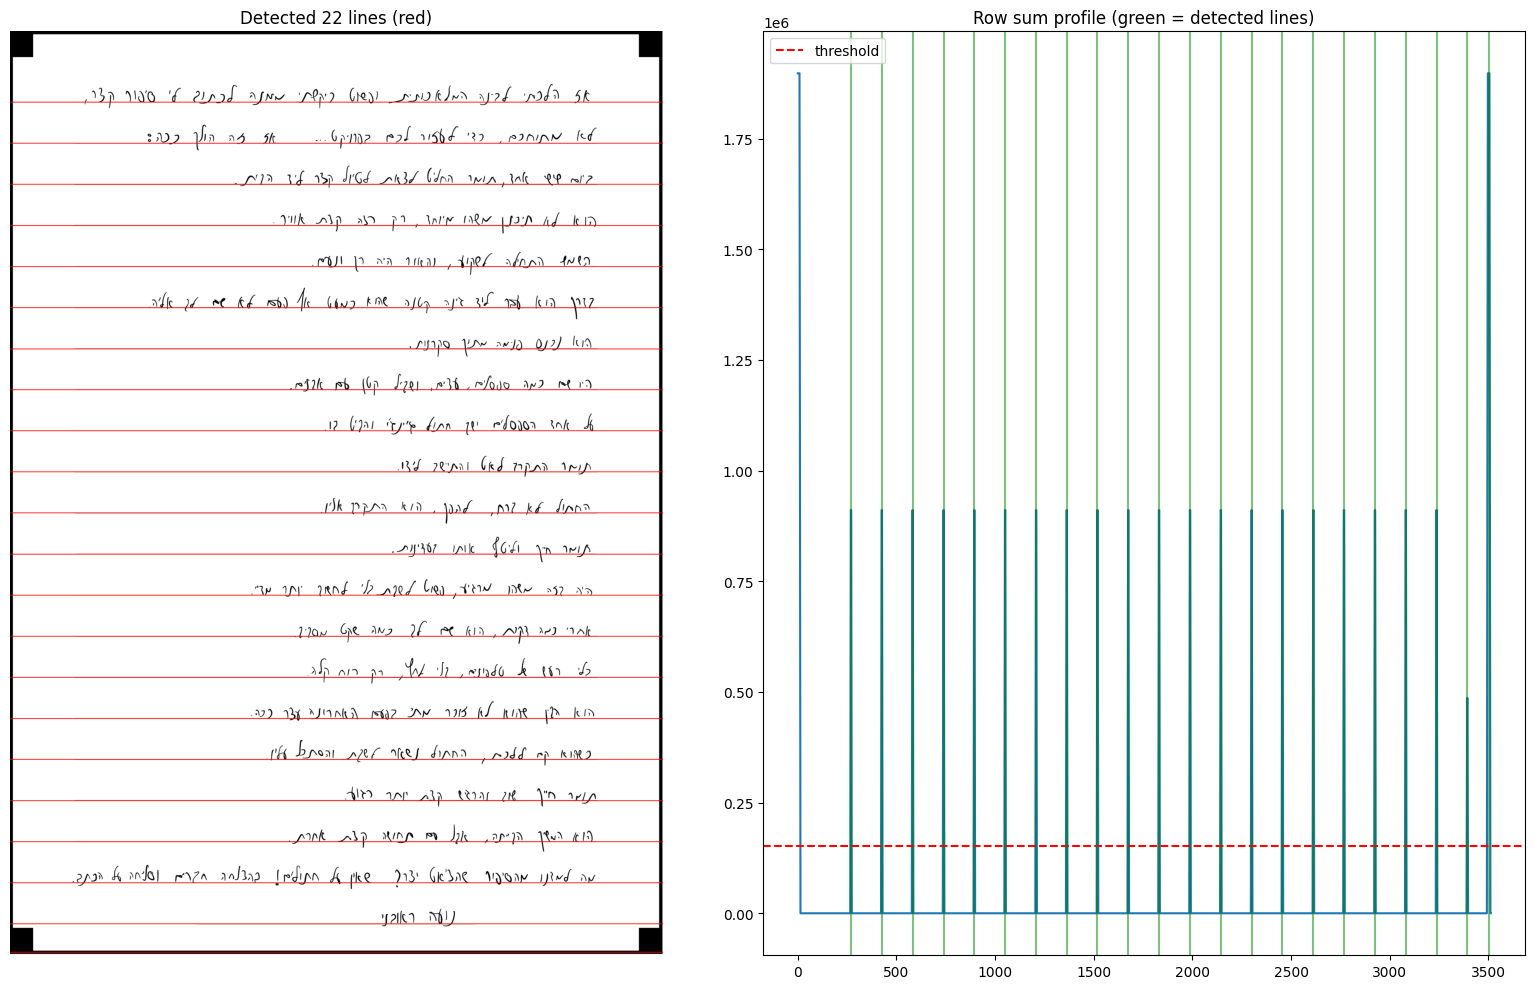

  Found 22 printed lines -> 21 crops
  Saved 21 line crops to 'cropped image to lines/attempt6'


In [6]:
!pip install pymupdf -q
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import fitz
from scipy.signal import find_peaks

INPUT_DIR  = "whole image"
OUT_DIR    = "cropped image to lines/attempt6"
os.makedirs(OUT_DIR, exist_ok=True)
OUTPUT_EXT   = ".png"
SKIP_TOP     = 10    # px to skip after the printed line (removes prev-row bleed)
PAD_BOTTOM   = 16   # px to add below the next printed line

# ── PDF loading ───────────────────────────────────────────────────────────────

def pdf_to_bgr_pages(path, dpi=300):
    doc   = fitz.open(path)
    scale = dpi / 72
    mat   = fitz.Matrix(scale, scale)
    pages = []
    for page in doc:
        pix = page.get_pixmap(matrix=mat)
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR if pix.n == 4 else cv2.COLOR_RGB2BGR)
        pages.append(img)
    return pages

def horizontal_line_score(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    _, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    h, w = binary.shape
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (max(1, w // 5), 1))
    lines_only = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    return cv2.countNonZero(lines_only)

def select_lined_page(path, dpi=300):
    pages = pdf_to_bgr_pages(path, dpi=dpi)
    if len(pages) == 1:
        return pages[0]
    scores = [horizontal_line_score(p) for p in pages]
    best = int(np.argmax(scores))
    print(f"  Line scores: {scores}  ->  using page {best + 1}")
    return pages[best]

# ── detect printed horizontal line positions ──────────────────────────────────

def detect_printed_lines(img, debug=False):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # Use multiple kernel widths and sum their row projections so that
    # partially-covered lines (broken by handwriting) still get detected
    _, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    row_sums = np.zeros(h, dtype=float)
    for kw in [w // 12, w // 8, w // 5]:
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kw, 1))
        mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
        row_sums += mask.sum(axis=1).astype(float)

    # Smooth to merge adjacent rows belonging to the same printed line
    from scipy.ndimage import uniform_filter1d
    row_sums = uniform_filter1d(row_sums, size=5)

    # Low threshold so faint lines aren't missed
    min_dist  = h // 50
    threshold = row_sums.max() * 0.08
    peaks, _  = find_peaks(row_sums, height=threshold, distance=min_dist)

    if debug:
        fig, axes = plt.subplots(1, 2, figsize=(16, 10))
        vis = img.copy()
        for y in peaks:
            cv2.line(vis, (0, int(y)), (w, int(y)), (0, 0, 255), 2)
        axes[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Detected {len(peaks)} lines (red)")
        axes[0].axis("off")
        axes[1].plot(row_sums)
        axes[1].axhline(threshold, color="r", linestyle="--", label="threshold")
        for y in peaks:
            axes[1].axvline(y, color="g", alpha=0.5)
        axes[1].set_title("Row sum profile (green = detected lines)")
        axes[1].legend()
        plt.tight_layout()
        plt.show()

    return sorted(peaks.tolist())

# ── crop between lines ────────────────────────────────────────────────────────

def crop_lines(img, line_ys, out_dir, basename, skip_top=SKIP_TOP, pad_bottom=PAD_BOTTOM):
    h, w = img.shape[:2]
    saved = 0
    for i in range(len(line_ys) - 1):
        y1 = min(h, line_ys[i]     + skip_top)   # start just after the printed line
        y2 = min(h, line_ys[i + 1] + pad_bottom) # show a bit below the next line
        crop = img[y1:y2, :]
        name = f"{basename}_line_{i+1:02d}{OUTPUT_EXT}"
        cv2.imwrite(os.path.join(out_dir, name), crop)
        saved += 1
    return saved

# ── run ───────────────────────────────────────────────────────────────────────

pdf_files = sorted(glob.glob(os.path.join(INPUT_DIR, "*.pdf")))
if not pdf_files:
    raise FileNotFoundError(f"No PDF files found in {INPUT_DIR!r}")

for pdf_path in pdf_files:
    base = os.path.splitext(os.path.basename(pdf_path))[0]
    print()
    print(f"Processing: {pdf_path}")

    img = select_lined_page(pdf_path)
    print(f"  Page size: {img.shape[1]} x {img.shape[0]} px")

    line_ys = detect_printed_lines(img, debug=True)
    print(f"  Found {len(line_ys)} printed lines -> {len(line_ys)-1} crops")

    if len(line_ys) < 2:
        print("  Not enough lines detected — skipping")
        continue

    n = crop_lines(img, line_ys, OUT_DIR, base)
    print(f"  Saved {n} line crops to {OUT_DIR!r}")
